In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("NetSentry EDA started")

NetSentry EDA started


In [2]:
import sys

sys.path.append("../")

from src.preprocessing.load_data import load_ciciot_data

print("Loader imported successfully")

Loader imported successfully


In [3]:
import pandas as pd

DATA_PATH = "../data/processed/ciciot_sample.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(499968, 40)


In [4]:
df.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,20.0,6,64.0,47148.201439,0.0,0.0,0.0,1.0,1.0,0.0,...,6000.0,60.0,60.0,60.00,0.0,60.00,0.000021,100.0,0.00,DDOS-PSHACK_FLOOD
1,20.0,6,64.0,74684.900285,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.00,0.0,60.00,0.000013,100.0,0.00,DOS-TCP_FLOOD
2,20.0,6,64.0,34709.566369,0.0,0.0,0.0,1.0,1.0,0.0,...,6000.0,60.0,60.0,60.00,0.0,60.00,0.000029,100.0,0.00,DDOS-PSHACK_FLOOD
3,19.8,6,64.0,23062.099302,0.0,0.0,0.0,0.0,0.0,0.0,...,6038.0,60.0,98.0,60.38,3.8,60.38,0.000043,100.0,14.44,DOS-TCP_FLOOD
4,20.0,6,64.0,20921.308859,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.00,0.0,60.00,0.000048,100.0,0.00,DDOS-TCP_FLOOD


In [5]:
df.columns

Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='str')

Step 1: Checking catagories.

In [8]:
df["Label"].value_counts()

Label
DDOS-ICMP_FLOOD            77064
DDOS-UDP_FLOOD             57610
DDOS-TCP_FLOOD             47889
DDOS-PSHACK_FLOOD          43726
DDOS-SYN_FLOOD             43185
DDOS-RSTFINFLOOD           42838
DDOS-SYNONYMOUSIP_FLOOD    38307
DOS-UDP_FLOOD              34809
DOS-TCP_FLOOD              28175
DOS-SYN_FLOOD              21678
BENIGN                     11494
MIRAI-GREETH_FLOOD         10525
MIRAI-UDPPLAIN              9352
MIRAI-GREIP_FLOOD           7962
DDOS-ICMP_FRAGMENTATION     4960
VULNERABILITYSCAN           4018
MITM-ARPSPOOFING            3277
DDOS-ACK_FRAGMENTATION      3048
DDOS-UDP_FRAGMENTATION      3026
DNS_SPOOFING                1928
RECON-HOSTDISCOVERY         1487
RECON-OSSCAN                1002
RECON-PORTSCAN               849
DOS-HTTP_FLOOD               761
DDOS-HTTP_FLOOD              285
DDOS-SLOWLORIS               249
DICTIONARYBRUTEFORCE         149
COMMANDINJECTION              80
SQLINJECTION                  69
BROWSERHIJACKING              67
BACK

Step 2: Calculating Proportion.

In [9]:
label_distribution = (
    df["Label"]
    .value_counts(normalize=True)
    .mul(100)
)

label_distribution

Label
DDOS-ICMP_FLOOD            15.413786
DDOS-UDP_FLOOD             11.522737
DDOS-TCP_FLOOD              9.578413
DDOS-PSHACK_FLOOD           8.745760
DDOS-SYN_FLOOD              8.637553
DDOS-RSTFINFLOOD            8.568148
DDOS-SYNONYMOUSIP_FLOOD     7.661890
DOS-UDP_FLOOD               6.962246
DOS-TCP_FLOOD               5.635361
DOS-SYN_FLOOD               4.335877
BENIGN                      2.298947
MIRAI-GREETH_FLOOD          2.105135
MIRAI-UDPPLAIN              1.870520
MIRAI-GREIP_FLOOD           1.592502
DDOS-ICMP_FRAGMENTATION     0.992063
VULNERABILITYSCAN           0.803651
MITM-ARPSPOOFING            0.655442
DDOS-ACK_FRAGMENTATION      0.609639
DDOS-UDP_FRAGMENTATION      0.605239
DNS_SPOOFING                0.385625
RECON-HOSTDISCOVERY         0.297419
RECON-OSSCAN                0.200413
RECON-PORTSCAN              0.169811
DOS-HTTP_FLOOD              0.152210
DDOS-HTTP_FLOOD             0.057004
DDOS-SLOWLORIS              0.049803
DICTIONARYBRUTEFORCE        0.02

Step 3: Drawing cata graphs.

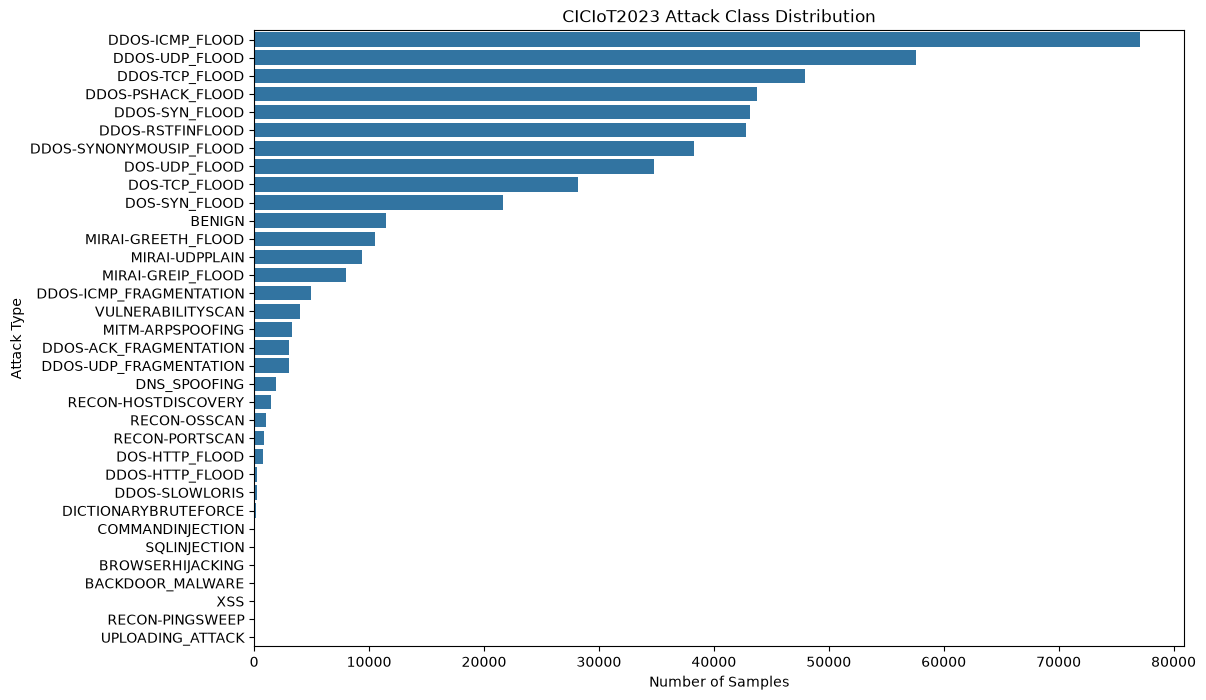

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="Label",
    order=df["Label"].value_counts().index
)

plt.title(
    "CICIoT2023 Attack Class Distribution"
)

plt.xlabel("Number of Samples")
plt.ylabel("Attack Type")

plt.show()

Step 4: Checking types.

In [11]:
df.dtypes.value_counts()

float64    38
int64       1
str         1
Name: count, dtype: int64

Step 5: Missing values

In [12]:
df.isnull().sum()

Header_Length      0
Protocol Type      0
Time_To_Live       0
Rate               0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IGMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                2
Tot size           0
IAT                0
Number             0
Variance           2
Label              0
dtype: int64

In [13]:
numeric_features = df.drop(columns="Label")

duplicate_count = df.duplicated().sum()
infinite_count = np.isinf(numeric_features.to_numpy()).sum()

constant_features = (
    numeric_features
    .nunique(dropna=False)
    .loc[lambda values: values <= 1]
)

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Infinite values: {infinite_count:,}")
print("\nConstant features:")
print(constant_features)

Duplicate rows: 99,764
Infinite values: 3

Constant features:
Series([], dtype: int64)
